# Loading Extracted Data to Pandas

In [50]:
import pandas as pd

df = pd.read_csv("electricity_demand.csv")
df.head()

,Year,Domestic & Small Commercial,Industrial (Large & Medium),Street Lighting,Rural Electrification,Total Demand(Gwh)
0,2024,4459.1,5515.2,89.9,684.79,10748.99
1,2023,4252.4,5299.8,109.1,659.36,10320.66
2,2022,4291.5,4958.2,94.2,664.47,10008.37
3,2021,4088.6,4728.4,99.6,648.80,9565.40
4,2020,3829.1,4281.0,74.5,611.90,8796.50


# Cleaning and Structuring Data

In [51]:
df.columns = [
    "Year",
    "Domestic",
    "Industrial",
    "Street_Lighting",
    "Rural",
    "Total_Demand"
]

In [52]:
df.sample(10)

,Year,Domestic,Industrial,Street_Lighting,Rural,Total_Demand
37,1987,616.0,1580.0,14.0,0.0,2210.0
15,2009,2058.1,3058.1,21.3,254.4,5391.9
20,2004,1416.6,2587.0,7.2,156.5,4167.3
47,1977,339.0,812.0,11.0,0.0,1162.0
19,2005,1507.7,2753.5,8.5,175.8,4445.5
43,1981,438.0,1096.0,11.0,0.0,1545.0
3,2021,4088.6,4728.4,99.6,648.8,9565.4
32,1992,877.0,1835.0,14.0,85.0,2811.0
18,2006,1572.4,2919.8,10.0,205.6,4707.8
40,1984,514.0,1206.0,9.0,0.0,1729.0


# Demand Analysis
## Visualization of the total demand trend

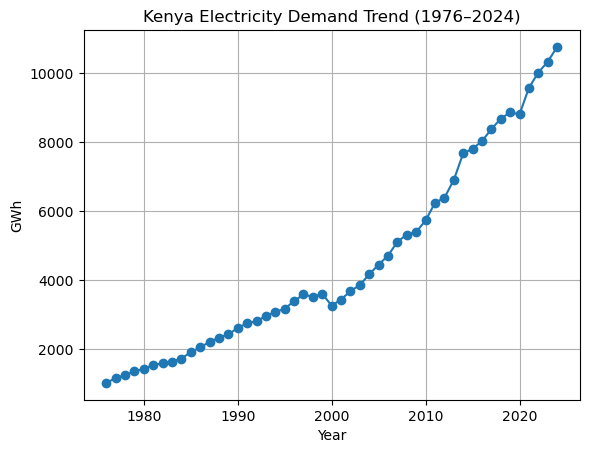

In [53]:
import matplotlib.pyplot as plt

plt.plot(df["Year"], df["Total_Demand"], marker='o')
plt.grid(True)
plt.title("Kenya Electricity Demand Trend (1976–2024)")
plt.xlabel("Year")
plt.ylabel("GWh")
plt.show()

## Sector Comparison

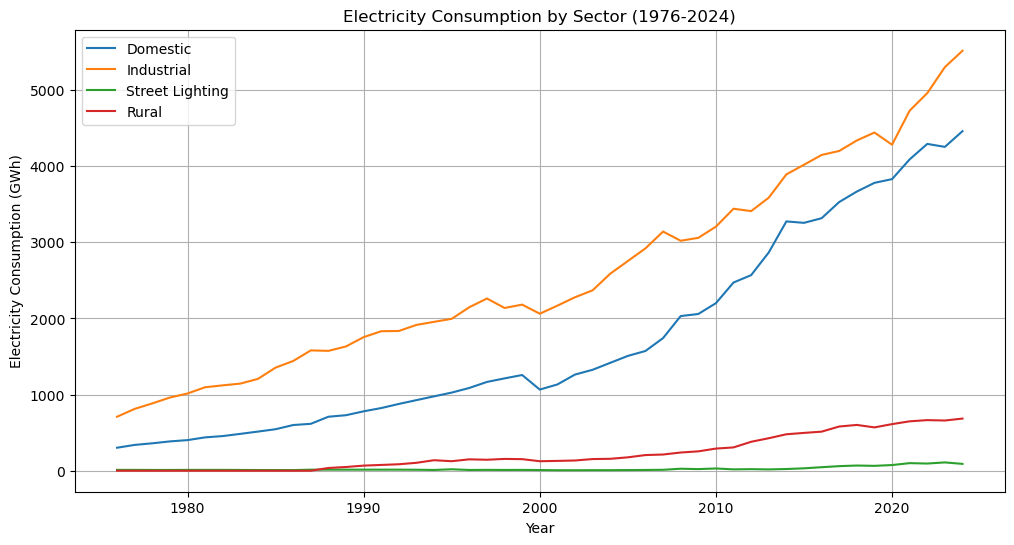

In [54]:
plt.figure(figsize=(12,6))

plt.plot(df['Year'], df['Domestic'], label='Domestic')
plt.plot(df['Year'], df['Industrial'], label='Industrial')
plt.plot(df['Year'], df['Street_Lighting'], label='Street Lighting')
plt.plot(df['Year'], df['Rural'], label='Rural')

plt.xlabel('Year')
plt.ylabel('Electricity Consumption (GWh)')
plt.title('Electricity Consumption by Sector (1976-2024)')
plt.legend()
plt.grid(True)

plt.show()

## Sector Share 2024

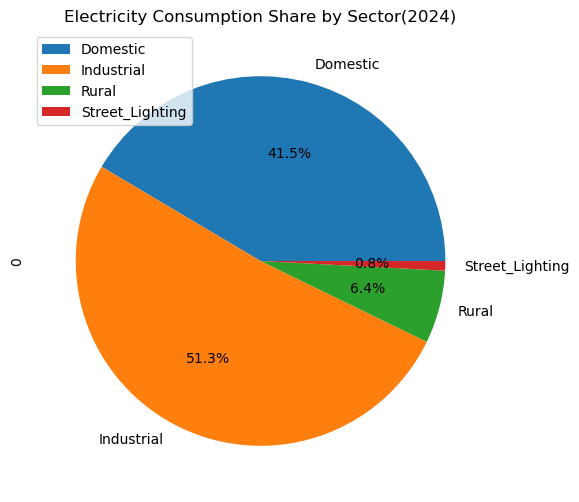

In [55]:
latest = df[df["Year"] == 2024]

latest[["Domestic","Industrial","Rural","Street_Lighting"]].T.plot(kind="pie",autopct="%1.1f%%",figsize=(6,6), subplots=True)
plt.title("Electricity Consumption Share by Sector(2024)")
plt.show()

### Insights

- The industrial sector accounts for the largest share of electricity consumption in 2024, contributing more than half of the total demand.

- Domestic consumption represents the second largest share, indicating significant electricity usage at the household level.

- Rural electricity consumption forms a relatively small portion of the total, highlighting lower access or usage in rural areas compared to urban and industrial regions.

- Street lighting contributes a negligible share to overall electricity demand, making it the smallest consumer among all sectors.

- The dominance of industrial and domestic sectors shows that electricity demand in Kenya is primarily driven by economic activity and residential needs.


- The concentration of electricity consumption in industrial and domestic sectors indicates an uneven distribution of energy usage, which may reflect infrastructure development patterns and urban concentration.

- Increasing the share of rural consumption could be a key indicator of successful rural electrification programs and inclusive energy access.

# Generation and Imports
- The generation and imports table will be loaded using pandas.

In [56]:
gen_df = pd.read_csv("generation_mix.csv")
gen_df.head(10)

,Year,Hydro,Thermal,Geothermal,Wind,Solar,Total
0,2024,3630.7,1129.5,5551.0,1797.7,460.40,12569.30
1,2023,2666.7,1305.7,6032.1,2008.1,491.50,12504.10
2,2022,3039.9,1584.9,5517.5,2143.0,383.70,12669.00
3,2021,3675.0,1262.0,5037.0,1984.8,167.40,12126.20
4,2020,4232.7,754.5,5059.8,1331.4,88.40,11466.80
5,2019,3205.3,1313.3,5234.7,1562.7,92.30,11408.30
6,2018,3986.4,1545.8,5127.8,375.6,13.68,11049.28
7,2017,2776.8,2534.1,4756.3,61.3,0.00,10128.50
8,2016,3959.9,1470.9,4484.2,56.4,0.00,9971.40
9,2015,3463.3,1412.1,4520.7,59.7,0.00,9455.80


## Cleaning and Structuring Data

In [57]:
gen_df.columns = [
    "Year",
    "Hydro",
    "Thermal",
    "Geothermal",
    "Wind",
    "Solar",
    "Total_Supply"
]


### Merging the Demand, Generation and Supply Datasets

In [58]:
df = pd.merge(df, gen_df, on="Year")
df.head()

,Year,Domestic,Industrial,Street_Lighting,Rural,Total_Demand,Hydro,Thermal,Geothermal,Wind,Solar,Total_Supply
0,2024,4459.1,5515.2,89.9,684.79,10748.99,3630.7,1129.5,5551.0,1797.7,460.4,12569.3
1,2023,4252.4,5299.8,109.1,659.36,10320.66,2666.7,1305.7,6032.1,2008.1,491.5,12504.1
2,2022,4291.5,4958.2,94.2,664.47,10008.37,3039.9,1584.9,5517.5,2143.0,383.7,12669.0
3,2021,4088.6,4728.4,99.6,648.80,9565.40,3675.0,1262.0,5037.0,1984.8,167.4,12126.2
4,2020,3829.1,4281.0,74.5,611.90,8796.50,4232.7,754.5,5059.8,1331.4,88.4,11466.8


## Analysis
### Energy Mix over Time

<Figure size 1200x600 with 0 Axes>

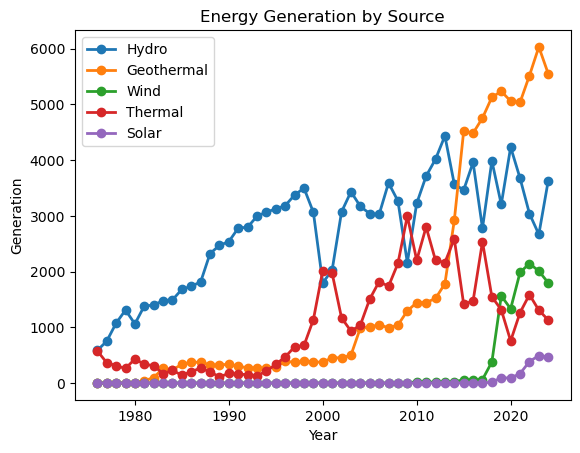

In [59]:
plt.figure(figsize=(12,6))

gen_df.set_index("Year")[["Hydro","Geothermal","Wind","Thermal","Solar"]].plot(linewidth=2,marker='o')
plt.title("Energy Generation by Source")
plt.xlabel("Year")
plt.ylabel("Generation")
plt.show()

##Insights
- Hydropower dominated early generation, supplying most electricity from the late 1970s to around 2015, but later became unstable showing large fluctuations.
- Geothermal shows the strongest sustained growth, rising sharply after 2013 and becoming the leading source in recent years.
- Thermal generation increased temporarily (2000–2015) but declined after 2018 as cleaner energy sources expanded.
- Wind energy growth was stagnant for years until recently, emerging after 2018 and growing steadily, though still moderate in share.
- Solar energy remains the smallest contributor, with only gradual growth in recent years.
- Overall trend: Kenya’s energy mix has shifted from heavy hydropower dependence to a more diversified system led by geothermal energy.

### Supply vs Demand

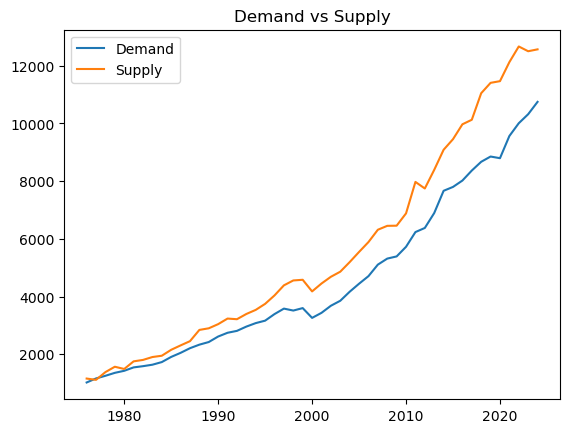

In [60]:
plt.plot(df["Year"], df["Total_Demand"], label="Demand")
plt.plot(df["Year"], df["Total_Supply"], label="Supply")
plt.legend()
plt.title("Demand vs Supply")
plt.show()

## Insights
- Both demand and supply shows a strong upward trend over the years, indicating continous market growth
- The widening gap between demand and supply may indicate increased power technical losses,  illegal connections, or infrastructure limitations rather than excess generation.